# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

from IPython.display import display, Audio

import matplotlib as mpl

mpl.rcParams['axes.facecolor'] = '#f7f7f7'

## Chapter 7: DFT invertibility

----

In [2]:
fin = "bin/48224__slothrop__trumpetf3.wav"

print(sf.info(fin))

bin/48224__slothrop__trumpetf3.wav
samplerate: 44100 Hz
channels: 1
duration: 38912 samples
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]


In [3]:
x, fs = sf.read(fin)

display("jello!")
display(Audio(data=x, rate=fs))

'jello!'

In [4]:
trunc_x = x[int(0.3*fs):  int(0.3*fs)+512]
trunc_t = np.arange(len(trunc_x))

X = np.fft.rfft(trunc_x)
mag_X = np.abs(X)

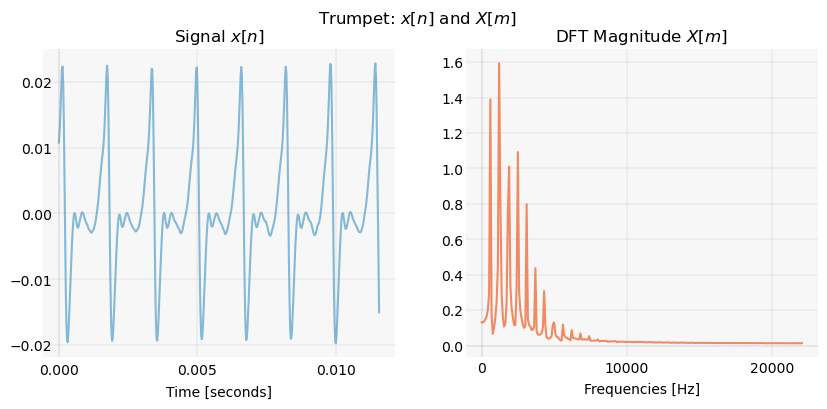

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# 1st plot for x in Time domain...
axes[0].plot(trunc_t, trunc_x, color='#67a9cf', alpha=0.8, zorder=-1)

axes[0].grid(True, linewidth=0.3, color='grey', alpha=0.4)
axes[0].set_title('Signal $x[n]$')
# Eliminate upper and right axes
axes[0].spines['right'].set_color('none')
axes[0].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[0].spines['left'].set_position('zero')
axes[0].spines['left'].set_color('grey')
axes[0].spines['left'].set_alpha(0.4)
axes[0].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[0].spines['bottom'].set_color('#f7f7f7')
axes[0].spines['bottom'].set_alpha(0.4)
axes[0].spines['bottom'].set_linewidth(0.3)
axes[0].set_xlabel('Time [seconds]')
axes[0].xaxis.set_label_coords(0.5, -0.09)
axes[0].set_xticks([0, 221, 442], ['0.000', '0.005', '0.010'])
axes[0].tick_params(left=False, bottom=False, pad=1)

# -----------------------------------
# 2nd plot for the corresponding DFT
freq_idx = np.arange(X.size)
axes[1].plot(freq_idx, mag_X, color='#ef8a62')

axes[1].grid(True, linewidth=0.3, color='grey', alpha=0.4)
axes[1].set_title('DFT Magnitude $X[m]$')
# Eliminate upper and right axes
axes[1].spines['right'].set_color('none')
axes[1].spines['top'].set_color('none')
axes[1].spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[1].spines['left'].set_position('zero')
axes[1].spines['left'].set_color('grey')
axes[1].spines['left'].set_alpha(0.4)
axes[1].spines['left'].set_linewidth(0.3)
axes[1].tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
axes[1].spines['bottom'].set_position('zero')
axes[1].spines['bottom'].set_color('grey')
axes[1].spines['bottom'].set_alpha(0.4)
axes[1].spines['bottom'].set_linewidth(0.3)
axes[1].set_xlabel('Frequencies [Hz]')
axes[1].xaxis.set_label_coords(0.5, -0.08)
axes[1].set_xticks([0, 116, 232], ['0', '10000', '20000'])
axes[1].tick_params(left=False, bottom=False, pad=8)

plt.suptitle('Trumpet: $x[n]$ and $X[m]$')
plt.show()